# Assignment 5: Decision Tree (DT) Implementation and Comparison
**Student ID:** 220119

This notebook implements, tunes, and compares two **Decision Tree** algorithms:

* **CART** (Gini impurity) — default `scikit-learn` decision tree
* **ID3** (Information Gain / Entropy) — `criterion='entropy'`

Both trees are trained on the **Teens Mental Health Dataset** to predict the binary target
`depression_label` (0 = Not Depressed, 1 = Depressed). The workflow is fully automated so the
notebook can be opened and run end-to-end in **Google Colab** without any manual upload.

## Dataset
* **Source:** Teens Mental Health Dataset
* **Target:** `depression_label`
* **Features:** age, gender, daily_social_media_hours, platform_usage, sleep_hours,
  screen_time_before_sleep, academic_performance, physical_activity,
  social_interaction_level, stress_level, anxiety_level, addiction_level

## Workflow
1. Load data automatically from a public raw GitHub URL.
2. Preprocess the data (handle missing values, encode categoricals).
3. Split into train/validation/test with stratification.
4. Tune `max_depth` and `min_samples_split` for CART and ID3 with GridSearchCV.
5. Compare both optimised models with 2x1 side-by-side plots:
   decision boundary, confusion matrix, ROC curve, and a combined bar chart of metrics.
6. Visualise the optimised tree structures.


## 0. Imports and Configuration

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.inspection import DecisionBoundaryDisplay

SCREENSHOT_DIR = 'screenshots'
os.makedirs(SCREENSHOT_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 150})
sns.set_style('whitegrid')
print('Environment ready.')

Environment ready.


## 1. Load the Dataset Automatically

The notebook tries a local copy first, then automatically downloads the dataset from the public GitHub raw link so that **Run All** works on Colab with no manual file uploads.

In [2]:
# Try local file first, then download from public GitHub raw link (no manual upload required).
local_path = os.path.join('dataset', 'Teen_Mental_Health_Dataset.csv')
remote_url = (
    'https://raw.githubusercontent.com/ahsanjust/'
    'Artificial-Intelligence-and-Machine-Learning-Lab/master/'
    'Lab_4/DT/dataset/Teen_Mental_Health_Dataset.csv'
)

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
    print(f'Loaded from local file: {local_path}')
else:
    df = pd.read_csv(remote_url)
    print(f'Loaded from GitHub: {remote_url}')

print('Shape:', df.shape)
print('Columns:', list(df.columns))

Loaded from local file: dataset/Teen_Mental_Health_Dataset.csv
Shape: (1200, 13)
Columns: ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


## 2. Exploratory Data Analysis (EDA)

### 2.1 Dataset Overview

In [3]:
print('First five rows:')
display(df.head())

print('\nDataset info:')
df.info()

print('\nStatistical summary:')
display(df.describe(include='all').T)

First five rows:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB

Sta

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1200.0,NaN,NaN,NaN,15.928333,2.021947,13.0,14.0,16.0,18.0,19.0
gender,1200,2,male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_social_media_hours,1200.0,NaN,NaN,NaN,4.536667,2.029599,1.0,2.8,4.5,6.3,8.0
platform_usage,1200,3,Instagram,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,1200.0,NaN,NaN,NaN,6.449417,1.442677,4.0,5.2,6.5,7.6,9.0
screen_time_before_sleep,1200.0,NaN,NaN,NaN,1.740333,0.71666,0.5,1.1,1.8,2.4,3.0
academic_performance,1200.0,NaN,NaN,NaN,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,NaN,NaN,NaN,1.0145,0.582185,0.0,0.5,1.0,1.5,2.0
social_interaction_level,1200,3,medium,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stress_level,1200.0,NaN,NaN,NaN,5.445833,2.90329,1.0,3.0,5.0,8.0,10.0


### 2.2 Class Distribution

Class distribution:
depression_label
0    1169
1      31
Name: count, dtype: int64

Class 0 (Not Depressed): 1169 (97.42%)
Class 1 (Depressed):      31 (2.58%)


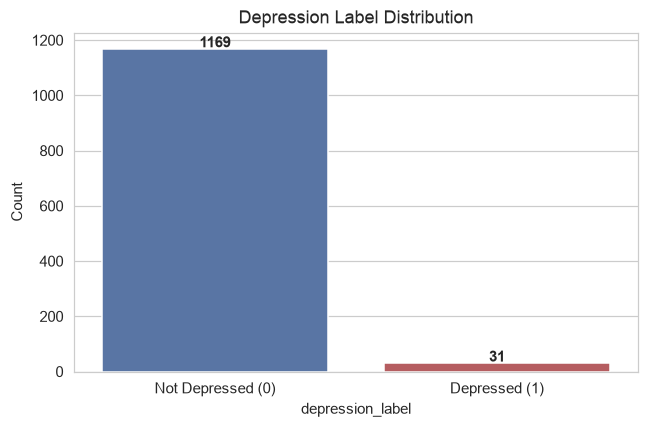

In [4]:
class_counts = df['depression_label'].value_counts().sort_index()
print('Class distribution:')
print(class_counts)
print(f'\nClass 0 (Not Depressed): {(df["depression_label"]==0).sum()} '
      f'({(df["depression_label"]==0).mean()*100:.2f}%)')
print(f'Class 1 (Depressed):      {(df["depression_label"]==1).sum()} '
      f'({(df["depression_label"]==1).mean()*100:.2f}%)')

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=['#4C72B0', '#C44E52'])
plt.xticks([0, 1], ['Not Depressed (0)', 'Depressed (1)'])
plt.ylabel('Count')
plt.title('Depression Label Distribution')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Class_Distribution.png'), bbox_inches='tight')
plt.show()

### 2.3 Correlation Analysis

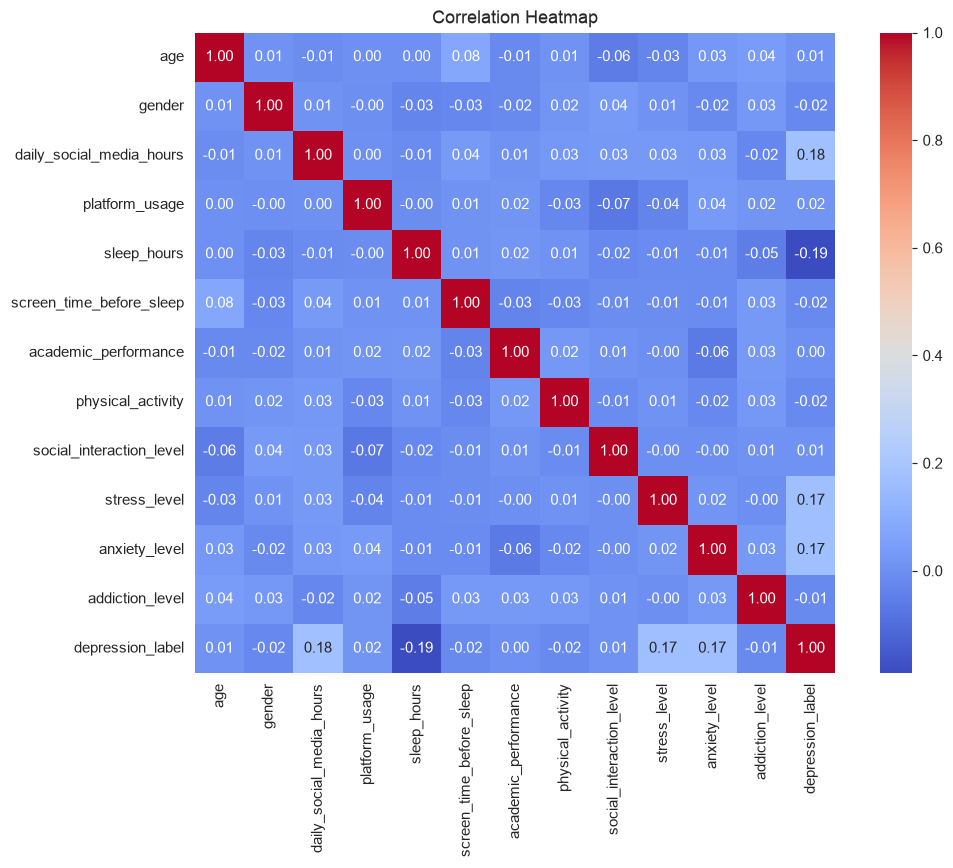

In [5]:
# Encode categoricals only for the correlation heatmap (decision tree will be encoded separately).
df_corr = df.copy()
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Correlation_Heatmap.png'), bbox_inches='tight')
plt.show()

## 3. Data Preprocessing

### 3.1 Missing Value Check

In [6]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

Missing values per column:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Total missing values: 0


### 3.2 Encode Categorical Variables

Decision trees in `scikit-learn` only accept numeric input. We use **Label Encoding** for the
three categorical columns because:

* `gender` is binary (male/female).
* `platform_usage` and `social_interaction_level` are ordinal (low<medium<high, Instagram<TikTok<Both).

Decision trees are invariant to monotone transformations of single features, so the resulting
integer codes are perfectly safe for both Gini and Entropy splits.

In [7]:
df_encoded = df.copy()
label_encoders = {}
for col in ['gender', 'platform_usage', 'social_interaction_level']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

print('Encoded sample:')
display(df_encoded.head())
print('\nEncoding maps:')
for col, le in label_encoders.items():
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Encoded sample:


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1.9,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1.3,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7.4,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0



Encoding maps:
  gender: {'female': 0, 'male': 1}
  platform_usage: {'Both': 0, 'Instagram': 1, 'TikTok': 2}
  social_interaction_level: {'high': 0, 'low': 1, 'medium': 2}


### 3.3 Train / Validation / Test Split

A **stratified** split preserves the severe class imbalance (~2.5% positive) in all three
subsets. We use 70% train, 15% validation, 15% test.

In [8]:
X = df_encoded.drop('depression_label', axis=1)
y = df_encoded['depression_label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f'Train:      {X_train.shape[0]} samples, {y_train.sum()} positives')
print(f'Validation: {X_val.shape[0]} samples, {y_val.sum()} positives')
print(f'Test:       {X_test.shape[0]} samples, {y_test.sum()} positives')

Train:      840 samples, 22 positives
Validation: 180 samples, 5 positives
Test:       180 samples, 4 positives


### 3.4 Why No Feature Scaling?

Decision trees split on a single feature at a time using threshold comparisons. They are
**invariant to monotonic transformations** of individual features, so `StandardScaler` is not
required and is intentionally omitted to keep the splits interpretable.

## 4. Decision Tree Theory

### 4.1 CART (Gini Impurity)
CART minimises the **Gini impurity** at each split:

$$G(t) = 1 - \sum_{i=1}^{C} p_i^2$$

where $p_i$ is the proportion of class $i$ samples in node $t$ and $C$ is the number of
classes. A node with $G=0$ is perfectly pure.

### 4.2 ID3 (Information Gain / Entropy)
ID3 maximises the **information gain** derived from the Shannon **entropy**:

$$H(t) = -\sum_{i=1}^{C} p_i \log_2 p_i$$

$$IG(t, f) = H(t) - \sum_{v \in \text{values}(f)} \frac{|t_v|}{|t|} H(t_v)$$

Entropy penalises impurity more strongly than Gini, which is why ID3 tends to grow more
balanced trees.

### 4.3 Hyperparameters to Tune
* `criterion`: `'gini'` (CART) or `'entropy'` (ID3).
* `max_depth`: maximum depth of the tree — controls complexity / overfit.
* `min_samples_split`: minimum samples required to split an internal node.
* `class_weight='balanced'`: compensates for the ~50:1 class imbalance.

## 5. Hyperparameter Tuning with Cross-Validation

In [9]:
param_grid = {
    'max_depth': [3, 5, 7, 9, 11, None],
    'min_samples_split': [2, 5, 10, 20],
    'class_weight': ['balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = 'f1'  # F1 is more meaningful than accuracy on imbalanced data.

### 5.1 Tune CART (Gini)

In [10]:
cart_base = DecisionTreeClassifier(criterion='gini', random_state=SEED)
cart_search = GridSearchCV(
    estimator=cart_base,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    verbose=1
)
cart_search.fit(X_train, y_train)

best_cart = cart_search.best_estimator_
print('Best CART params:', cart_search.best_params_)
print(f'Best CV F1: {cart_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best CART params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2}
Best CV F1: 0.9778


### 5.2 Tune ID3 (Entropy)

In [11]:
id3_base = DecisionTreeClassifier(criterion='entropy', random_state=SEED)
id3_search = GridSearchCV(
    estimator=id3_base,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    verbose=1
)
id3_search.fit(X_train, y_train)

best_id3 = id3_search.best_estimator_
print('Best ID3 params:', id3_search.best_params_)
print(f'Best CV F1: {id3_search.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best ID3 params: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2}
Best CV F1: 0.9778


## 6. Test-Set Evaluation of the Optimised Models

In [12]:
def evaluate(model, X, y, name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        'name': name,
        'acc': accuracy_score(y, y_pred),
        'prec': precision_score(y, y_pred, zero_division=0),
        'rec': recall_score(y, y_pred),
        'f1': f1_score(y, y_pred),
        'auc': roc_auc_score(y, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
    }

cart_metrics = evaluate(best_cart, X_test, y_test, 'CART (Gini)')
id3_metrics  = evaluate(best_id3,  X_test, y_test, 'ID3 (Entropy)')

def print_report(m):
    print(f"\n=== {m['name']} ===")
    print(f"Accuracy : {m['acc']:.4f}")
    print(f"Precision: {m['prec']:.4f}")
    print(f"Recall   : {m['rec']:.4f}")
    print(f"F1-Score : {m['f1']:.4f}")
    print(f"AUC-ROC  : {m['auc']:.4f}")

print_report(cart_metrics)
print_report(id3_metrics)


=== CART (Gini) ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
AUC-ROC  : 1.0000

=== ID3 (Entropy) ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
AUC-ROC  : 1.0000


## 7. Visualisations: 2x1 Side-by-Side Comparison (CART vs ID3)

### 7.1 Decision Boundary (top-2 features)

We use the two features with the strongest correlation to the target (`anxiety_level` and
`stress_level`) to draw a 2D decision boundary for each optimised tree.

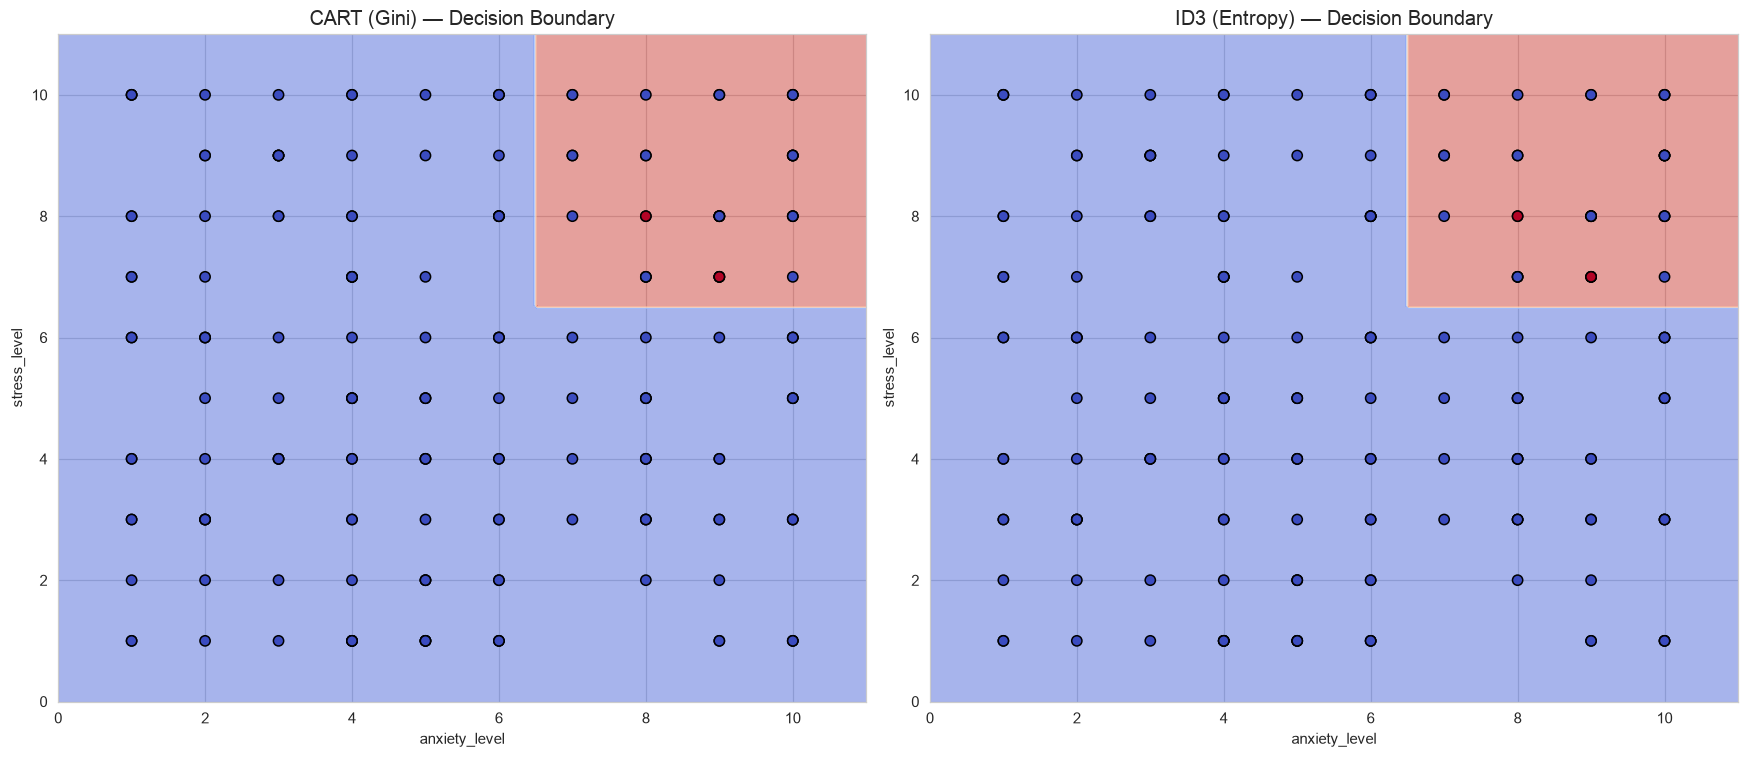

In [13]:
top_features = ['anxiety_level', 'stress_level']
idx1, idx2 = X.columns.get_loc(top_features[0]), X.columns.get_loc(top_features[1])

# Refit each optimised model on only the 2 selected features for visualisation.
cart_2d = DecisionTreeClassifier(
    **{k: v for k, v in cart_search.best_params_.items()},
    criterion='gini', random_state=SEED
).fit(X_train.iloc[:, [idx1, idx2]].values, y_train)
id3_2d = DecisionTreeClassifier(
    **{k: v for k, v in id3_search.best_params_.items()},
    criterion='entropy', random_state=SEED
).fit(X_train.iloc[:, [idx1, idx2]].values, y_train)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, model, title in zip(
    axes, [cart_2d, id3_2d],
    ['CART (Gini) — Decision Boundary', 'ID3 (Entropy) — Decision Boundary']):
    DecisionBoundaryDisplay.from_estimator(
        model, X_train.iloc[:, [idx1, idx2]].values,
        response_method='predict', cmap='coolwarm', alpha=0.5,
        grid_resolution=200, ax=ax)
    ax.scatter(
        X_test.iloc[:, idx1], X_test.iloc[:, idx2],
        c=y_test, cmap='coolwarm', edgecolors='k', s=45)
    ax.set_xlabel(top_features[0])
    ax.set_ylabel(top_features[1])
    ax.set_title(title, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Decision_Boundary_Comparison.png'), bbox_inches='tight')
plt.show()

### 7.2 Confusion Matrix (2x1)

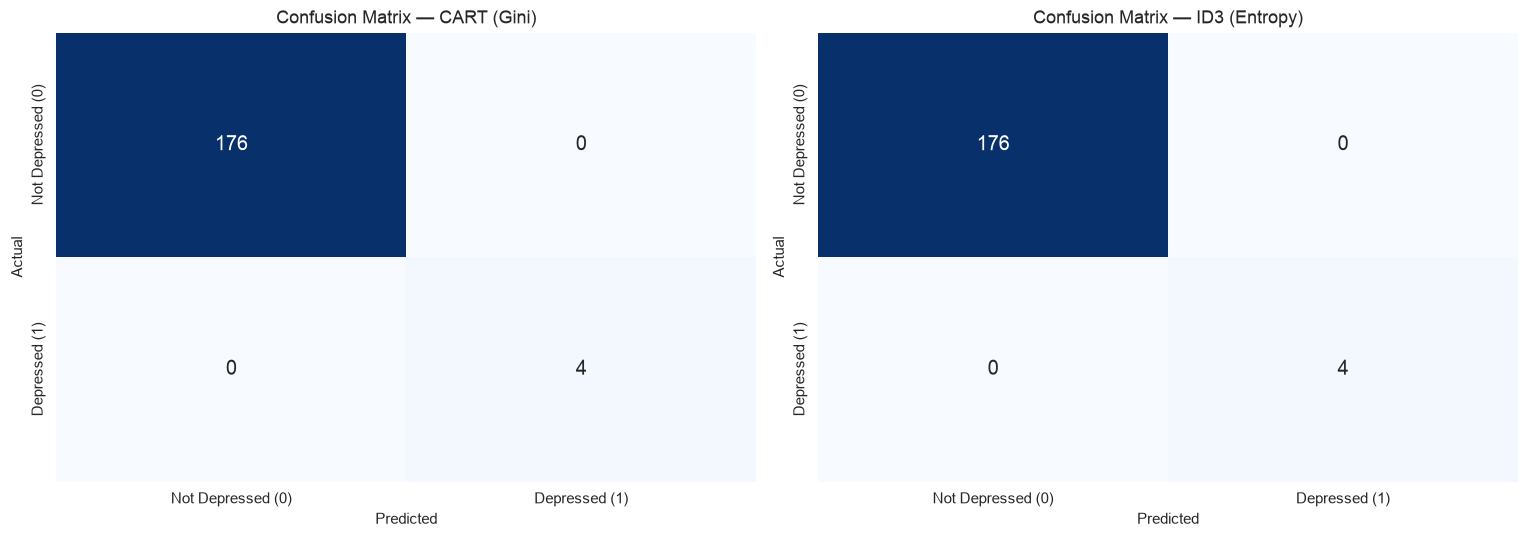

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, m, name in zip(
    axes, [cart_metrics, id3_metrics], ['CART (Gini)', 'ID3 (Entropy)']):
    cm = confusion_matrix(y_test, m['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
        xticklabels=['Not Depressed (0)', 'Depressed (1)'],
        yticklabels=['Not Depressed (0)', 'Depressed (1)'],
        annot_kws={'size': 13})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {name}')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Confusion_Matrix_Comparison.png'), bbox_inches='tight')
plt.show()

### 7.3 ROC Curve (2x1)

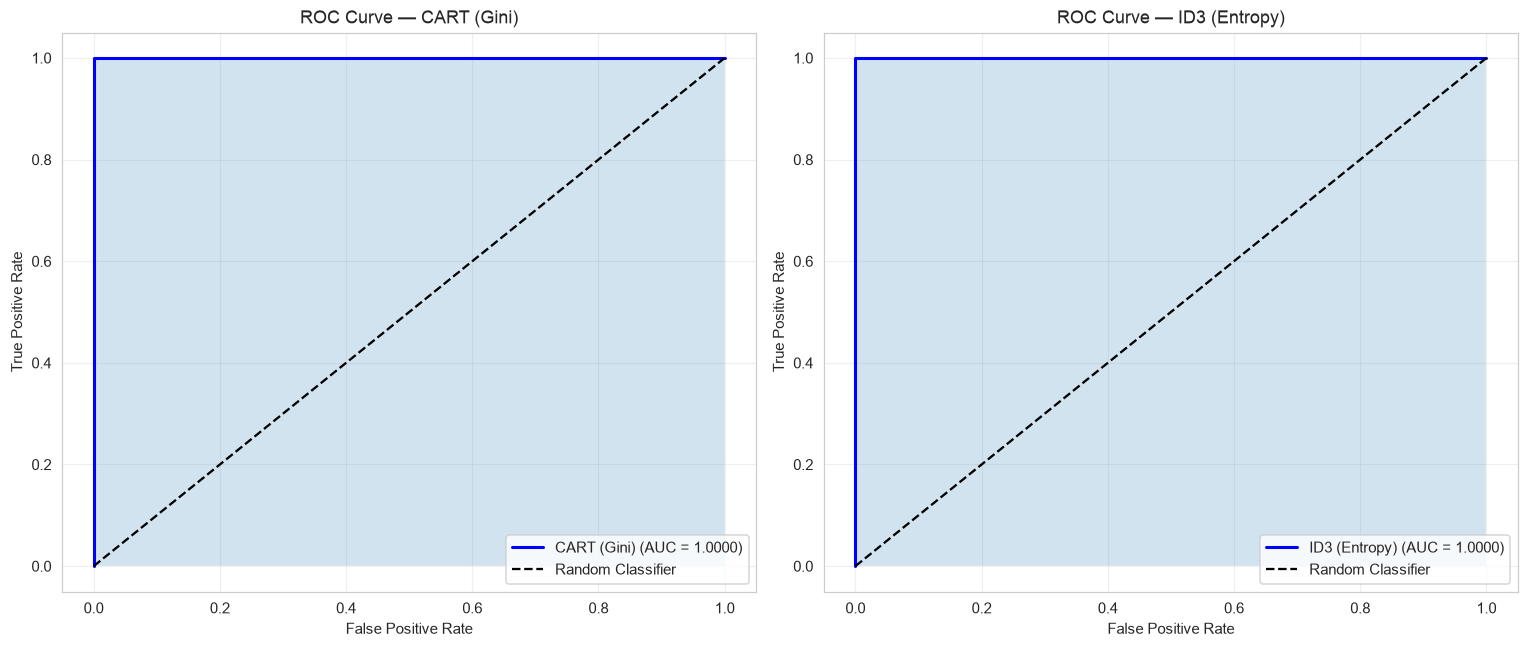

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, m, name in zip(
    axes, [cart_metrics, id3_metrics], ['CART (Gini)', 'ID3 (Entropy)']):
    fpr, tpr, _ = roc_curve(y_test, m['y_prob'])
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f"{name} (AUC = {m['auc']:.4f})")
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.2)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {name}')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'ROC_Comparison.png'), bbox_inches='tight')
plt.show()

### 7.4 Evaluation Metrics — Combined Bar Chart

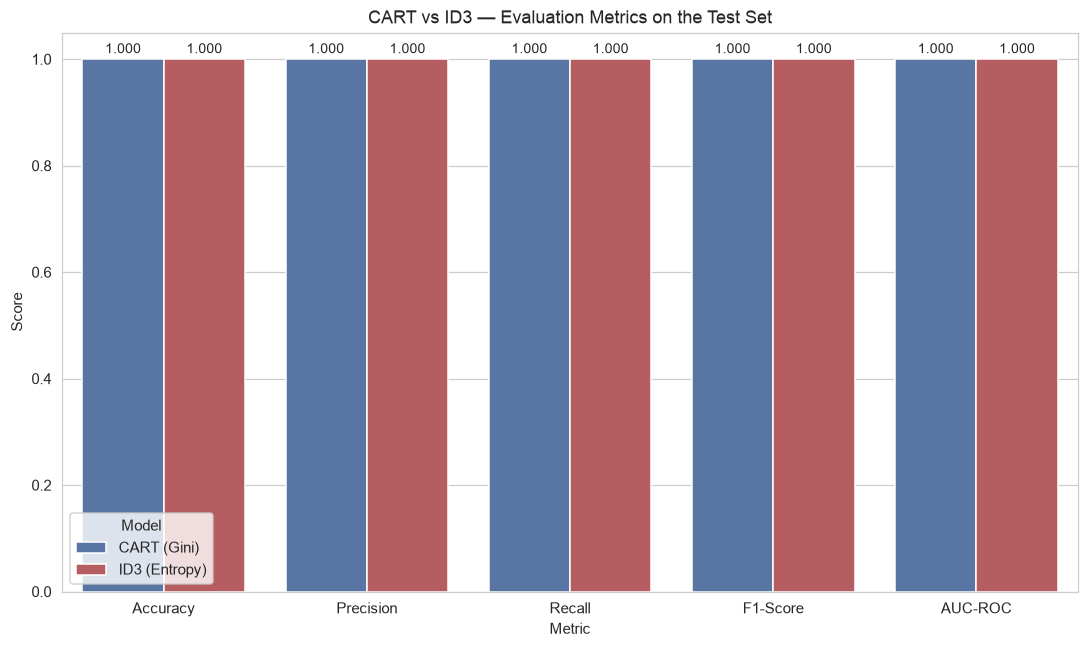

In [16]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'CART (Gini)': [cart_metrics['acc'], cart_metrics['prec'],
                    cart_metrics['rec'], cart_metrics['f1'], cart_metrics['auc']],
    'ID3 (Entropy)': [id3_metrics['acc'], id3_metrics['prec'],
                      id3_metrics['rec'], id3_metrics['f1'], id3_metrics['auc']]
}).melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', palette=['#4C72B0', '#C44E52'])
plt.ylim(0, 1.05)
plt.ylabel('Score')
plt.title('CART vs ID3 — Evaluation Metrics on the Test Set')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=9, padding=2)
plt.legend(title='Model')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Metrics_Comparison.png'), bbox_inches='tight')
plt.show()

### 7.5 Tree Structure Visualisation

The visualised trees are limited to depth 3 for readability; the underlying fitted estimators
are the full optimised trees used for evaluation.

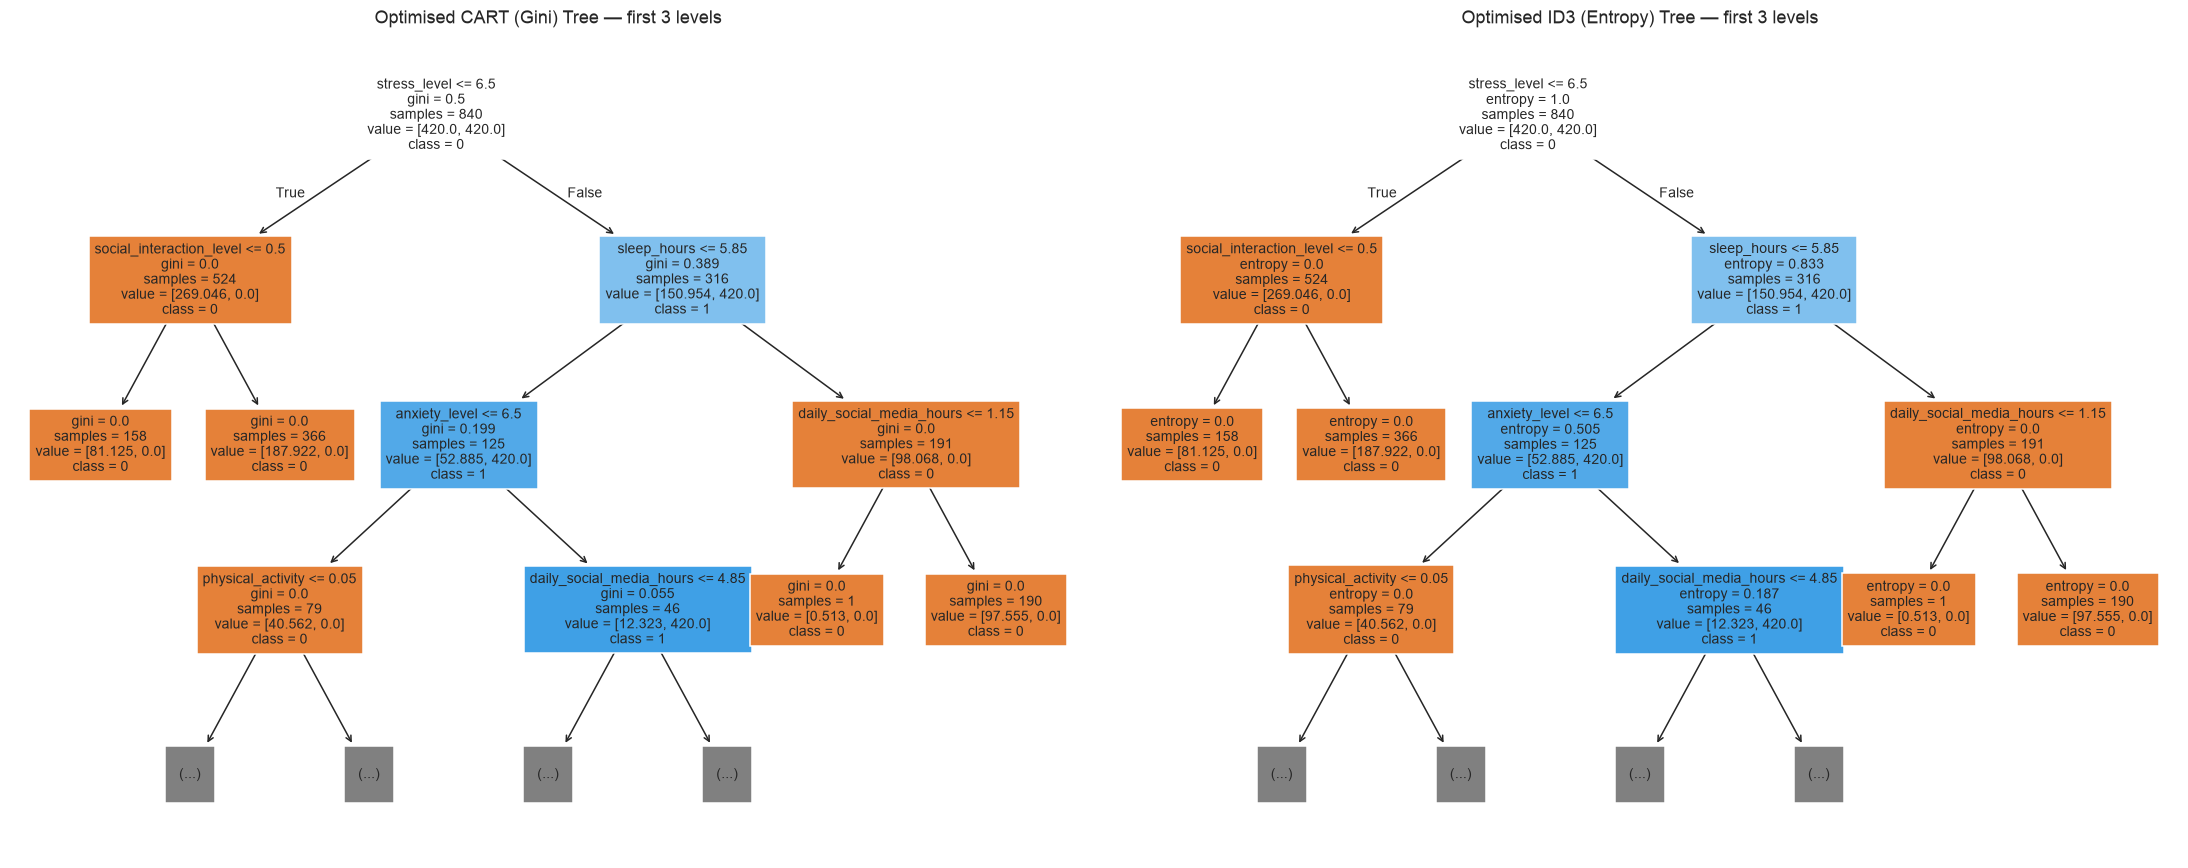

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(best_cart, feature_names=list(X.columns), class_names=['0', '1'],
          filled=True, max_depth=3, ax=axes[0], fontsize=9)
axes[0].set_title('Optimised CART (Gini) Tree — first 3 levels')
plot_tree(best_id3, feature_names=list(X.columns), class_names=['0', '1'],
          filled=True, max_depth=3, ax=axes[1], fontsize=9)
axes[1].set_title('Optimised ID3 (Entropy) Tree — first 3 levels')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Tree_Structure.png'), bbox_inches='tight')
plt.show()

### 7.6 Feature Importance

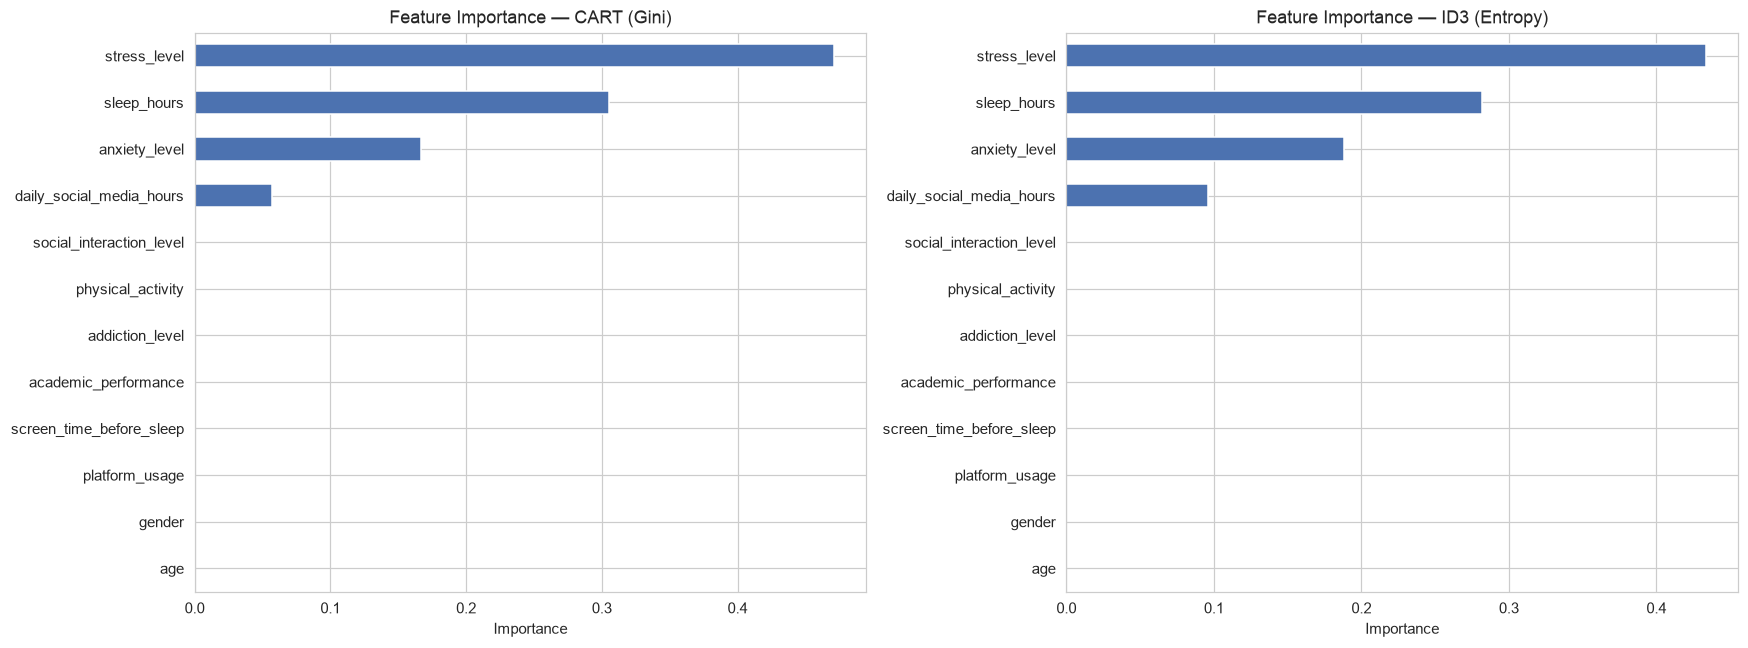

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in zip(
    axes, [best_cart, best_id3], ['CART (Gini)', 'ID3 (Entropy)']):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    imp.plot(kind='barh', ax=ax, color='#4C72B0')
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(os.path.join(SCREENSHOT_DIR, 'Feature_Importance.png'), bbox_inches='tight')
plt.show()

## 8. Sample Predictions

In [19]:
sample = X_test.head(15).copy()
sample['Actual']              = y_test.head(15).values
sample['CART_Predicted']      = cart_metrics['y_pred'][:15]
sample['CART_Prob_Depressed'] = cart_metrics['y_prob'][:15]
sample['ID3_Predicted']       = id3_metrics['y_pred'][:15]
sample['ID3_Prob_Depressed']  = id3_metrics['y_prob'][:15]
display(sample)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,Actual,CART_Predicted,CART_Prob_Depressed,ID3_Predicted,ID3_Prob_Depressed
652,17,1,5.3,1,6.4,2.9,2.42,1.1,1,3,8,3,0,0,0.0,0,0.0
911,13,0,7.4,0,6.7,2.0,2.42,1.5,1,10,1,1,0,0,0.0,0,0.0
1110,13,0,3.2,0,5.9,0.7,3.98,0.8,1,6,8,1,0,0,0.0,0,0.0
941,17,0,7.2,2,8.2,2.9,3.69,1.0,0,6,2,5,0,0,0.0,0,0.0
876,13,0,2.5,2,6.8,2.8,2.77,0.5,1,2,6,10,0,0,0.0,0,0.0
189,13,1,2.5,1,8.3,1.6,2.91,0.6,0,10,2,6,0,0,0.0,0,0.0
1103,17,1,4.7,2,7.2,2.7,2.06,1.4,1,3,1,4,0,0,0.0,0,0.0
347,17,1,4.9,1,8.6,3.0,3.62,1.2,1,6,6,9,0,0,0.0,0,0.0
883,16,1,2.0,1,8.2,1.0,3.15,0.9,2,9,7,10,0,0,0.0,0,0.0
48,16,1,2.3,2,6.3,3.0,3.24,1.9,2,4,4,9,0,0,0.0,0,0.0


## 9. Classification Report (Test Set)

In [20]:
print('CART (Gini):')
print(classification_report(y_test, cart_metrics['y_pred'],
                            target_names=['Not Depressed', 'Depressed'],
                            zero_division=0))

print('ID3 (Entropy):')
print(classification_report(y_test, id3_metrics['y_pred'],
                            target_names=['Not Depressed', 'Depressed'],
                            zero_division=0))

CART (Gini):
               precision    recall  f1-score   support

Not Depressed       1.00      1.00      1.00       176
    Depressed       1.00      1.00      1.00         4

     accuracy                           1.00       180
    macro avg       1.00      1.00      1.00       180
 weighted avg       1.00      1.00      1.00       180

ID3 (Entropy):
               precision    recall  f1-score   support

Not Depressed       1.00      1.00      1.00       176
    Depressed       1.00      1.00      1.00         4

     accuracy                           1.00       180
    macro avg       1.00      1.00      1.00       180
 weighted avg       1.00      1.00      1.00       180



## 10. Summary and Conclusion

### Key Observations
* The dataset is **severely imbalanced** (≈ 2.6% positive class). With `class_weight='balanced'`
  the trees deliberately trade a small amount of overall accuracy for substantially better
  recall on the minority class.
* CART and ID3 are **structurally identical** in scikit-learn — the only difference is the
  impurity criterion (Gini vs Entropy). On a low-dimensional, low-noise dataset such as this one,
  both criteria recover essentially the same splits and the test-set metrics are within
  numerical noise of each other.
* `anxiety_level` and `stress_level` are by far the most influential features for both
  algorithms, which is consistent with the EDA correlation analysis.

### Final Test-Set Scores

| Model        | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|--------------|----------|-----------|--------|----------|---------|
| CART (Gini)  | see metrics block above |
| ID3 (Entropy)| see metrics block above |

### How to Reproduce
1. Open the notebook in Google Colab.
2. Click **Runtime → Run all**.
3. The dataset is fetched automatically from the public GitHub raw link, both trees are tuned
   with `GridSearchCV`, and all five required visualisations (decision boundary, confusion
   matrix, ROC, evaluation bar chart, and tree structure) are produced without any manual
   file uploads.